# Sector ETF Performance Explorer

## How to use this notebook
This notebook documents the analytical workflow used to build the processed files for the Streamlit app.

For checking and reproduction, it is best to run the notebook from top to bottom using **Run All** or sequential execution. The markdown sections explain the purpose of each stage, while the code sections retrieve, clean, validate, and save the datasets used by the final app.

This notebook is designed to support the final interactive product, so its main role is to make the Python workflow clear, logical, and reproducible.

## Environment note

This notebook assumes that the required Python packages have already been installed in the current environment.

Please install dependencies from `requirements.txt` before running the notebook from top to bottom, for example:

`pip install -r requirements.txt`

## 1. Project Overview

**Project background:** individual stock selection can be fragmented and difficult to compare across sectors, especially when sector behaviour changes over time. 

**Target users:** beginner investors and finance students.

**Analytical problem:** compare sector ETFs in a clear and user-friendly way across performance, risk, diversification, holdings structure, and representative stock behaviour.

The final scope of the project includes **six sector ETFs**:
- XLK (Technology)
- XLE (Energy)
- XLF (Financials)
- XLV (Health Care)
- XLI (Industrials)
- XLP (Consumer Staples)

The project uses three core ETF risk-performance metrics:
- **Cumulative return**
- **Annualized volatility**
- **Maximum drawdown**

It also includes:
- official holdings snapshots,
- correlation analysis,
- and one representative stock for each ETF.

## 2. Data Sources and Reproducibility Note

**Data sources:**
- **WRDS - CRSP** for ETF and representative stock price data  
  - identifier table: `crsp.stocknames_v2`
  - daily price table: `crsp.dsf_v2`
- **Official SPDR holdings files** for holdings snapshots, downloaded manually

The data were collected in stages during project development. For clarity, this final notebook presents the **unified final workflow** for all 6 ETFs and 6 representative stocks together. Exact access dates and source details are documented in the README.

In [10]:
import os
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from IPython.display import display
import wrds

# ------------------------------
# Project paths and run settings
# ------------------------------
PROJECT_ROOT = Path(".")
DATA_DIR = PROJECT_ROOT / "data"
ETF_RAW_DIR = DATA_DIR / "raw_wrds"
RAW_DIR = DATA_DIR / "raw"
HOLDINGS_RAW_DIR = DATA_DIR / "raw_holdings"
PROCESSED_DIR = DATA_DIR / "processed"
REP_STOCK_DIR = PROCESSED_DIR / "representative_stock"
REP_RAW_DIR = RAW_DIR / "representative_stock"

for folder in [ETF_RAW_DIR, RAW_DIR, HOLDINGS_RAW_DIR, PROCESSED_DIR, REP_STOCK_DIR, REP_RAW_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

START_DATE = "2021-01-01"
END_DATE = "2025-12-31"
TRADING_DAYS_PER_YEAR = 252
ACCESS_DATE = date.today().isoformat()
WRDS_USERNAME = os.getenv("WRDS_USERNAME", "").strip()

# ------------------------------
# Final ETF scope and label maps
# ------------------------------
ETF_UNIVERSE = ["XLK", "XLE", "XLF", "XLV", "XLI", "XLP"]
OUTPUT_ETF_ORDER = sorted(ETF_UNIVERSE)

SECTOR_MAP = {
    "XLK": "Technology",
    "XLE": "Energy",
    "XLF": "Financials",
    "XLV": "Health Care",
    "XLI": "Industrials",
    "XLP": "Consumer Staples",
}

ETF_DISPLAY_NAME_MAP = {
    ticker: f"{ticker} ({SECTOR_MAP[ticker]})"
    for ticker in ETF_UNIVERSE
}

COLOR_MAP = {
    "XLK": "#FF7F0E",
    "XLE": "#2C7FB8",
    "XLF": "#2CA02C",
    "XLV": "#9467BD",
    "XLI": "#B85C4B",
    "XLP": "#A49A52",
}

REPRESENTATIVE_STOCK_MAP = {
    "XLK": "NVDA",
    "XLE": "XOM",
    "XLF": "JPM",
    "XLV": "LLY",
    "XLI": "CAT",
    "XLP": "PG",
}

REPRESENTATIVE_COMPANY_MAP = {
    "XLK": "NVIDIA CORP",
    "XLE": "EXXON MOBIL CORP",
    "XLF": "JPMORGAN CHASE & CO",
    "XLV": "LILLY ELI & CO",
    "XLI": "CATERPILLAR INC",
    "XLP": "PROCTER & GAMBLE CO",
}

WHY_SELECTED_MAP = {
    "XLK": "Representative large-cap technology stock",
    "XLE": "Representative large-cap energy stock",
    "XLF": "Representative large-cap financial stock",
    "XLV": "Representative large-cap health care stock",
    "XLI": "Representative large-cap industrial stock",
    "XLP": "Representative consumer staples stock",
}

representative_stock_plan = pd.DataFrame(
    [
        {
            "ETF": etf,
            "ETF_Display_Name": ETF_DISPLAY_NAME_MAP[etf],
            "Sector": SECTOR_MAP[etf],
            "Representative_Stock_Ticker": REPRESENTATIVE_STOCK_MAP[etf],
            "Representative_Company_Name": REPRESENTATIVE_COMPANY_MAP[etf],
            "Why_Selected": WHY_SELECTED_MAP[etf],
        }
        for etf in ETF_UNIVERSE
    ]
).sort_values("ETF").reset_index(drop=True)

# ------------------------------
# File paths used by the notebook
# ------------------------------
ETF_IDENTIFIERS_RAW_FILE = ETF_RAW_DIR / "etf_names_wrds.csv"
ETF_PRICES_RAW_FILE = ETF_RAW_DIR / "etf_prices_wrds_raw.csv"
ETF_WRDS_METADATA_FILE = ETF_RAW_DIR / "wrds_access_metadata.txt"
ETF_PRICES_CLEAN_FILE = PROCESSED_DIR / "etf_prices_clean.csv"
ETF_PRICES_METRICS_READY_FILE = PROCESSED_DIR / "etf_prices_metrics_ready.csv"
ETF_METRICS_SUMMARY_FILE = PROCESSED_DIR / "etf_metrics_summary.csv"
ETF_CLEANING_SUMMARY_FILE = PROCESSED_DIR / "etf_prices_cleaning_summary.txt"

HOLDINGS_FILE_MAP = {
    "XLK": HOLDINGS_RAW_DIR / "xlk_holdings.xlsx",
    "XLE": HOLDINGS_RAW_DIR / "xle_holdings.xlsx",
    "XLF": HOLDINGS_RAW_DIR / "xlf_holdings.xlsx",
    "XLV": HOLDINGS_RAW_DIR / "xlv_holdings.xlsx",
    "XLI": HOLDINGS_RAW_DIR / "xli_holdings.xlsx",
    "XLP": HOLDINGS_RAW_DIR / "xlp_holdings.xlsx",
}
HOLDINGS_ALL_FILE = PROCESSED_DIR / "holdings_all_clean.csv"
HOLDINGS_TOP10_FILE = PROCESSED_DIR / "holdings_top10.csv"
HOLDINGS_CLEANING_SUMMARY_FILE = PROCESSED_DIR / "holdings_cleaning_summary.txt"

REP_IDENTIFIERS_RAW_FILE = REP_RAW_DIR / "representative_stock_identifiers_wrds.csv"
REP_PRICES_RAW_FILE = REP_RAW_DIR / "representative_stock_prices_wrds_raw.csv"
REP_WRDS_METADATA_FILE = REP_RAW_DIR / "representative_stock_wrds_metadata.txt"
REP_MAPPING_FILE = REP_STOCK_DIR / "representative_stock_mapping.csv"
REP_CLEAN_FILE = REP_STOCK_DIR / "representative_stocks_clean.csv"
REP_METRICS_READY_FILE = REP_STOCK_DIR / "representative_stocks_metrics_ready.csv"
REP_SUMMARY_FILE = REP_STOCK_DIR / "representative_stocks_summary.csv"
REP_VALIDATION_FILE = REP_STOCK_DIR / "representative_stocks_validation_summary.txt"
FINAL_VALIDATION_FILE = PROCESSED_DIR / "dataset_validation_summary.txt"

ETF_PRICE_COLUMNS = [
    "Permno", "Ticker", "Date", "Open", "High", "Low", "Close", "Price", "Return", "Volume"
]
ETF_METRIC_COLUMNS = ETF_PRICE_COLUMNS + [
    "Growth_Index", "Cumulative_Return", "Running_Peak", "Drawdown"
]

HOLDINGS_COLUMNS = [
    "ETF",
    "Fund_Name",
    "Holdings_As_Of",
    "Holding_Name",
    "Holding_Ticker",
    "Identifier",
    "SEDOL",
    "Weight",
    "Sector",
    "Shares_Held",
    "Local_Currency",
]

REP_MAPPING_OPTIONAL_COLUMNS = [
    "Permco",
    "Security_Type",
    "Security_Subtype",
    "Share_Type",
    "Name_Start_Date",
    "Name_End_Date",
    "Security_Begin_Date",
    "Security_End_Date",
    "Primary_Exchange",
]
REP_MAPPING_COLUMNS = [
    "ETF",
    "ETF_Display_Name",
    "Sector",
    "Representative_Stock_Ticker",
    "Representative_Company_Name",
    "Why_Selected",
    "Permno",
] + REP_MAPPING_OPTIONAL_COLUMNS
REP_CLEAN_COLUMNS = [
    "ETF",
    "ETF_Display_Name",
    "Sector",
    "Representative_Stock_Ticker",
    "Representative_Company_Name",
    "Why_Selected",
    "Permno",
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Price",
    "Return",
    "Volume",
]
REP_METRIC_COLUMNS = REP_CLEAN_COLUMNS + [
    "Growth_Index", "Cumulative_Return", "Running_Peak", "Drawdown"
]
REP_SUMMARY_COLUMNS = [
    "ETF",
    "ETF_Display_Name",
    "Representative_Stock_Ticker",
    "Representative_Company_Name",
    "Why_Selected",
    "Start_Date",
    "End_Date",
    "Observations",
    "Final_Cumulative_Return",
    "Annualized_Volatility",
    "Max_Drawdown",
]

# ------------------------------
# Reusable helper functions
# ------------------------------
def format_sql_in(values):
    values = list(values)
    if not values:
        raise ValueError("The SQL IN list is empty.")

    formatted = []
    for value in values:
        if isinstance(value, str):
            formatted.append(f"'{value}'")
        else:
            formatted.append(str(value))
    return f"({', '.join(formatted)})"


def get_wrds_connection():
    global WRDS_USERNAME

    if not WRDS_USERNAME:
        WRDS_USERNAME = input("Enter your WRDS username: ").strip()

    if WRDS_USERNAME:
        return wrds.Connection(wrds_username=WRDS_USERNAME)
    return wrds.Connection()


def write_text_lines(path, lines):
    path.write_text("\n".join(str(line) for line in lines), encoding="utf-8")


def validate_expected_members(found_values, expected_values, label):
    found_sorted = sorted(pd.Series(found_values).dropna().astype(str).unique().tolist())
    expected_sorted = sorted(str(value) for value in expected_values)

    if found_sorted != expected_sorted:
        raise ValueError(
            f"{label} do not match the expected set. Found: {found_sorted}. Expected: {expected_sorted}."
        )
    return found_sorted


def latest_identifier_rows(df, ticker_col="ticker"):
    sort_cols = [ticker_col]
    for col in ["nameenddt", "namedt", "securityenddt", "securitybegdt"]:
        if col in df.columns:
            sort_cols.append(col)

    return (
        df.sort_values(sort_cols)
        .drop_duplicates(subset=[ticker_col], keep="last")
        .reset_index(drop=True)
    )


def compute_price_metrics(df, group_col):
    metrics_df = df.copy()
    metrics_df["Growth_Index"] = (
        metrics_df.groupby(group_col)["Return"]
        .transform(lambda series: (1 + series).cumprod())
    )
    metrics_df["Cumulative_Return"] = metrics_df["Growth_Index"] - 1
    metrics_df["Running_Peak"] = metrics_df.groupby(group_col)["Growth_Index"].cummax()
    metrics_df["Drawdown"] = metrics_df["Growth_Index"] / metrics_df["Running_Peak"] - 1
    return metrics_df


def build_performance_summary(df, group_cols):
    return (
        df.groupby(group_cols, as_index=False)
        .agg(
            Start_Date=("Date", "min"),
            End_Date=("Date", "max"),
            Observations=("Date", "count"),
            Final_Cumulative_Return=("Cumulative_Return", "last"),
            Annualized_Volatility=(
                "Return",
                lambda series: series.std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR),
            ),
            Max_Drawdown=("Drawdown", "min"),
        )
    )


def parse_spdr_holdings_file(etf_ticker, file_path):
    if not file_path.exists():
        raise FileNotFoundError(f"Holdings file not found: {file_path}")

    metadata = pd.read_excel(file_path, sheet_name="holdings", header=None, nrows=5, engine="openpyxl")
    fund_name = str(metadata.iloc[0, 1]).strip()
    ticker_in_file = str(metadata.iloc[1, 1]).strip().upper()
    holdings_as_of_text = str(metadata.iloc[2, 1]).replace("As of", "").strip()
    holdings_as_of = pd.to_datetime(holdings_as_of_text, format="%d-%b-%Y", errors="coerce")

    if ticker_in_file != etf_ticker:
        raise ValueError(
            f"Holdings file ticker mismatch for {file_path.name}. Found {ticker_in_file}, expected {etf_ticker}."
        )

    holdings = pd.read_excel(file_path, sheet_name="holdings", header=4, engine="openpyxl")
    holdings = holdings.dropna(axis=1, how="all").rename(
        columns={
            "Name": "Holding_Name",
            "Ticker": "Holding_Ticker",
            "Identifier": "Identifier",
            "SEDOL": "SEDOL",
            "Weight": "Weight",
            "Sector": "Sector",
            "Shares Held": "Shares_Held",
            "Local Currency": "Local_Currency",
        }
    )

    required_columns = [
        "Holding_Name",
        "Holding_Ticker",
        "Identifier",
        "SEDOL",
        "Weight",
        "Sector",
        "Shares_Held",
        "Local_Currency",
    ]
    missing_columns = [column for column in required_columns if column not in holdings.columns]
    if missing_columns:
        raise KeyError(f"Missing holdings columns for {etf_ticker}: {missing_columns}")

    holdings = holdings[required_columns].copy()
    holdings["Weight"] = pd.to_numeric(holdings["Weight"], errors="coerce")
    holdings["Shares_Held"] = pd.to_numeric(holdings["Shares_Held"], errors="coerce")
    holdings = holdings[holdings["Holding_Name"].notna() & holdings["Weight"].notna()].copy()
    holdings["ETF"] = etf_ticker
    holdings["Fund_Name"] = fund_name
    holdings["Holdings_As_Of"] = holdings_as_of

    return (
        holdings[HOLDINGS_COLUMNS]
        .sort_values(["Weight", "Holding_Name"], ascending=[False, True])
        .reset_index(drop=True)
    )


plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 180
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.20
plt.rcParams["grid.linestyle"] = "--"

print("Project configuration loaded.")
print(f"Analysis window: {START_DATE} to {END_DATE}")
print(f"Final ETF universe: {', '.join(ETF_UNIVERSE)}")
print("Representative stock mapping:")
display(representative_stock_plan)

Project configuration loaded.
Analysis window: 2021-01-01 to 2025-12-31
Final ETF universe: XLK, XLE, XLF, XLV, XLI, XLP
Representative stock mapping:


,ETF,ETF_Display_Name,Sector,Representative_Stock_Ticker,Representative_Company_Name,Why_Selected
0,XLE,XLE (Energy),Energy,XOM,EXXON MOBIL CORP,Representative large-cap energy stock
1,XLF,XLF (Financials),Financials,JPM,JPMORGAN CHASE & CO,Representative large-cap financial stock
2,XLI,XLI (Industrials),Industrials,CAT,CATERPILLAR INC,Representative large-cap industrial stock
3,XLK,XLK (Technology),Technology,NVDA,NVIDIA CORP,Representative large-cap technology stock
4,XLP,XLP (Consumer Staples),Consumer Staples,PG,PROCTER & GAMBLE CO,Representative consumer staples stock
5,XLV,XLV (Health Care),Health Care,LLY,LILLY ELI & CO,Representative large-cap health care stock


## 3. Access and Clean ETF Price Data

This section retrieves ETF identifier information and daily price data from WRDS / CRSP using SQL queries, then cleans, validates, and saves the ETF dataset.

The workflow first retrieves identifier data from `crsp.stocknames_v2` and daily price data from `crsp.dsf_v2`. It then standardises column names, sorts observations, converts date fields, checks membership coverage, and prepares a clean ETF price panel.

After cleaning, the section computes the main app-facing metrics, including daily return series, cumulative return, annualized volatility, and maximum drawdown.

The final workflow is presented for the full 6-ETF universe rather than as separate development stages. The outputs generated here are the processed ETF files used by the Streamlit app.

In [11]:
# ------------------------------
# 1. Retrieve ETF identifier and daily price data from WRDS
# ------------------------------
db = None
try:
    db = get_wrds_connection()

    sql_etf_identifiers = f"""
    SELECT
        permno,
        permco,
        ticker,
        issuernm,
        securitytype,
        securitysubtype,
        sharetype,
        namedt,
        nameenddt,
        securitybegdt,
        securityenddt,
        primaryexch
    FROM crsp.stocknames_v2
    WHERE ticker IN {format_sql_in(ETF_UNIVERSE)}
    ORDER BY ticker, namedt
    """

    etf_identifiers_raw = db.raw_sql(
        sql_etf_identifiers,
        date_cols=["namedt", "nameenddt", "securitybegdt", "securityenddt"],
    )
    raw_identifier_tickers = validate_expected_members(
        etf_identifiers_raw["ticker"].tolist(), ETF_UNIVERSE, "ETF identifiers"
    )

    etf_identifier_latest = latest_identifier_rows(etf_identifiers_raw, ticker_col="ticker")
    etf_identifier_latest = etf_identifier_latest[["permno", "ticker"]].copy()

    sql_etf_prices = f"""
    SELECT
        permno,
        dlycaldt,
        dlyopen,
        dlyhigh,
        dlylow,
        dlyclose,
        dlyprc,
        dlyret,
        dlyvol
    FROM crsp.dsf_v2
    WHERE permno IN {format_sql_in(etf_identifier_latest['permno'].astype(int).tolist())}
      AND dlycaldt BETWEEN '{START_DATE}' AND '{END_DATE}'
    ORDER BY permno, dlycaldt
    """

    etf_prices_raw = db.raw_sql(sql_etf_prices, date_cols=["dlycaldt"])
    etf_prices_raw = etf_prices_raw.merge(etf_identifier_latest, on="permno", how="left")
    etf_prices_raw = etf_prices_raw[
        [
            "permno",
            "ticker",
            "dlycaldt",
            "dlyopen",
            "dlyhigh",
            "dlylow",
            "dlyclose",
            "dlyprc",
            "dlyret",
            "dlyvol",
        ]
    ].copy()
    raw_price_tickers = validate_expected_members(
        etf_prices_raw["ticker"].tolist(), ETF_UNIVERSE, "ETF daily prices"
    )
    raw_duplicate_count = int(etf_prices_raw.duplicated(subset=["permno", "dlycaldt"]).sum())

    etf_identifiers_raw.to_csv(ETF_IDENTIFIERS_RAW_FILE, index=False, date_format="%Y-%m-%d")
    etf_prices_raw.to_csv(ETF_PRICES_RAW_FILE, index=False, date_format="%Y-%m-%d")
    write_text_lines(
        ETF_WRDS_METADATA_FILE,
        [
            "WRDS ETF Access Metadata",
            "========================",
            f"Access date: {ACCESS_DATE}",
            f"Date range: {START_DATE} to {END_DATE}",
            f"Requested ETFs: {', '.join(ETF_UNIVERSE)}",
            f"Identifier tickers found: {', '.join(raw_identifier_tickers)}",
            f"Daily price tickers found: {', '.join(raw_price_tickers)}",
            f"Permnos used: {', '.join(str(value) for value in etf_identifier_latest['permno'].astype(int).tolist())}",
            f"Identifier rows saved: {len(etf_identifiers_raw)}",
            f"Daily price rows saved: {len(etf_prices_raw)}",
            f"Duplicate permno-date rows in raw extract: {raw_duplicate_count}",
        ],
    )
finally:
    if db is not None:
        db.close()

print("WRDS ETF retrieval complete and the connection is closed.")

# ------------------------------
# 2. Clean and validate the ETF price dataset
# ------------------------------
etf_prices_clean = etf_prices_raw.rename(
    columns={
        "permno": "Permno",
        "ticker": "Ticker",
        "dlycaldt": "Date",
        "dlyopen": "Open",
        "dlyhigh": "High",
        "dlylow": "Low",
        "dlyclose": "Close",
        "dlyprc": "Price",
        "dlyret": "Return",
        "dlyvol": "Volume",
    }
).copy()

etf_prices_clean["Date"] = pd.to_datetime(etf_prices_clean["Date"], errors="coerce")
for column in ["Permno", "Open", "High", "Low", "Close", "Price", "Return", "Volume"]:
    etf_prices_clean[column] = pd.to_numeric(etf_prices_clean[column], errors="coerce")

etf_prices_clean["Price"] = etf_prices_clean["Price"].abs()
etf_prices_clean = (
    etf_prices_clean[ETF_PRICE_COLUMNS]
    .drop_duplicates(subset=["Ticker", "Date"], keep="last")
    .sort_values(["Ticker", "Date"])
    .reset_index(drop=True)
)
etf_prices_clean["Permno"] = etf_prices_clean["Permno"].astype("Int64")

clean_tickers = validate_expected_members(
    etf_prices_clean["Ticker"].tolist(), ETF_UNIVERSE, "Clean ETF prices"
)
clean_duplicate_count = int(etf_prices_clean.duplicated(subset=["Ticker", "Date"]).sum())
if clean_duplicate_count != 0:
    raise ValueError(f"ETF clean file still contains {clean_duplicate_count} duplicate ticker-date rows.")

etf_price_coverage = (
    etf_prices_clean.groupby("Ticker")["Date"]
    .agg(["min", "max", "count"])
    .reindex(OUTPUT_ETF_ORDER)
)
etf_price_missing = etf_prices_clean.isna().sum()

# ------------------------------
# 3. Compute ETF metrics and save app-ready outputs
# ------------------------------
etf_prices_metrics_ready = compute_price_metrics(etf_prices_clean, group_col="Ticker")
etf_prices_metrics_ready = etf_prices_metrics_ready[ETF_METRIC_COLUMNS].copy()

etf_metrics_summary = build_performance_summary(etf_prices_metrics_ready, ["Ticker"])
etf_metrics_summary = etf_metrics_summary.sort_values("Ticker").reset_index(drop=True)

if len(etf_metrics_summary) != len(ETF_UNIVERSE):
    raise ValueError("ETF metrics summary does not cover all 6 ETFs.")

etf_prices_clean.to_csv(ETF_PRICES_CLEAN_FILE, index=False, date_format="%Y-%m-%d")
etf_prices_metrics_ready.to_csv(ETF_PRICES_METRICS_READY_FILE, index=False, date_format="%Y-%m-%d")
etf_metrics_summary.to_csv(ETF_METRICS_SUMMARY_FILE, index=False, date_format="%Y-%m-%d")
write_text_lines(
    ETF_CLEANING_SUMMARY_FILE,
    [
        "ETF Price Cleaning Summary",
        "==========================",
        f"Final ETF universe: {', '.join(clean_tickers)}",
        f"Rows in clean ETF file: {len(etf_prices_clean)}",
        f"Rows in metrics-ready ETF file: {len(etf_prices_metrics_ready)}",
        f"Rows in ETF summary file: {len(etf_metrics_summary)}",
        f"Duplicate ticker-date rows: {clean_duplicate_count}",
        "",
        "Coverage summary:",
        etf_price_coverage.to_string(),
        "",
        "Missing values by column:",
        etf_price_missing.to_string(),
    ],
)

print("ETF processed outputs saved for the app.")
print(f"Clean price file: {ETF_PRICES_CLEAN_FILE}")
print(f"Metrics-ready price file: {ETF_PRICES_METRICS_READY_FILE}")
print(f"ETF summary file: {ETF_METRICS_SUMMARY_FILE}")
display(etf_metrics_summary)

Loading library list...
Done
WRDS ETF retrieval complete and the connection is closed.
ETF processed outputs saved for the app.
Clean price file: data/processed/etf_prices_clean.csv
Metrics-ready price file: data/processed/etf_prices_metrics_ready.csv
ETF summary file: data/processed/etf_metrics_summary.csv


,Ticker,Start_Date,End_Date,Observations,Final_Cumulative_Return,Annualized_Volatility,Max_Drawdown
0,XLE,2021-01-04,2025-12-31,1255,1.846869,0.267013,-0.260841
1,XLF,2021-01-04,2025-12-31,1255,1.025064,0.188693,-0.258184
2,XLI,2021-01-04,2025-12-31,1255,0.890441,0.172114,-0.216556
3,XLK,2021-01-04,2025-12-31,1255,1.302495,0.247044,-0.335645
4,XLP,2021-01-04,2025-12-31,1255,0.312687,0.130119,-0.16323
5,XLV,2021-01-04,2025-12-31,1255,0.477671,0.144799,-0.171152


## 4. Clean ETF Holdings Data

This section cleans the official SPDR holdings files downloaded manually for all 6 ETFs.

Holdings are treated as **snapshot data** rather than a historical daily series. They are used to explain ETF composition in the app, especially through the full holdings table and the top-10 holdings view.

In [12]:
# ------------------------------
# 1. Parse and combine the six holdings files
# ------------------------------
holdings_frames = []
for etf_ticker in ETF_UNIVERSE:
    cleaned_holdings = parse_spdr_holdings_file(etf_ticker, HOLDINGS_FILE_MAP[etf_ticker])
    holdings_frames.append(cleaned_holdings)

holdings_all_clean = pd.concat(holdings_frames, ignore_index=True)
holdings_all_clean = (
    holdings_all_clean.sort_values(["ETF", "Weight", "Holding_Name"], ascending=[True, False, True])
    .reset_index(drop=True)
)

holdings_top10 = (
    holdings_all_clean.groupby("ETF", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

# ------------------------------
# 2. Validate the final holdings outputs
# ------------------------------
holdings_etfs_found = validate_expected_members(
    holdings_all_clean["ETF"].tolist(), ETF_UNIVERSE, "Holdings ETFs"
)
holdings_row_count_by_etf = holdings_all_clean.groupby("ETF").size().reindex(OUTPUT_ETF_ORDER)
holdings_top10_count_by_etf = holdings_top10.groupby("ETF").size().reindex(OUTPUT_ETF_ORDER)
holdings_weight_sum_by_etf = holdings_all_clean.groupby("ETF")["Weight"].sum().reindex(OUTPUT_ETF_ORDER)
holdings_missing_all = holdings_all_clean.isna().sum()
holdings_missing_top10 = holdings_top10.isna().sum()

if not (holdings_top10_count_by_etf == 10).all():
    raise ValueError("The top-10 holdings file does not contain exactly 10 rows for every ETF.")

# ------------------------------
# 3. Save the app-facing holdings files
# ------------------------------
holdings_all_clean.to_csv(HOLDINGS_ALL_FILE, index=False, date_format="%Y-%m-%d")
holdings_top10.to_csv(HOLDINGS_TOP10_FILE, index=False, date_format="%Y-%m-%d")
write_text_lines(
    HOLDINGS_CLEANING_SUMMARY_FILE,
    [
        "Holdings Cleaning Summary",
        "========================",
        f"ETFs found: {', '.join(holdings_etfs_found)}",
        f"Rows in full holdings file: {len(holdings_all_clean)}",
        f"Rows in top-10 holdings file: {len(holdings_top10)}",
        "",
        "Full holdings row counts by ETF:",
        holdings_row_count_by_etf.to_string(),
        "",
        "Top-10 row counts by ETF:",
        holdings_top10_count_by_etf.to_string(),
        "",
        "Weight sums by ETF:",
        holdings_weight_sum_by_etf.to_string(),
        "",
        "Missing values in holdings_all_clean.csv:",
        holdings_missing_all.to_string(),
        "",
        "Missing values in holdings_top10.csv:",
        holdings_missing_top10.to_string(),
    ],
)

print("Holdings processed outputs saved for the app.")
print(f"Full holdings file: {HOLDINGS_ALL_FILE}")
print(f"Top-10 holdings file: {HOLDINGS_TOP10_FILE}")
display(holdings_top10.groupby("ETF", group_keys=False).head(3))

Holdings processed outputs saved for the app.
Full holdings file: data/processed/holdings_all_clean.csv
Top-10 holdings file: data/processed/holdings_top10.csv


,ETF,Fund_Name,Holdings_As_Of,Holding_Name,Holding_Ticker,Identifier,SEDOL,Weight,Sector,Shares_Held,Local_Currency
0,XLE,State Street® Energy Select Sector SPDR® ETF,2026-04-16,EXXON MOBIL CORP,XOM,30231G102,2326618,23.037955,-,59738107.0,USD
1,XLE,State Street® Energy Select Sector SPDR® ETF,2026-04-16,CHEVRON CORP,CVX,166764100,2838555,17.044231,-,35699912.0,USD
2,XLE,State Street® Energy Select Sector SPDR® ETF,2026-04-16,CONOCOPHILLIPS,COP,20825C104,2685717,7.197879,-,23333080.0,USD
10,XLF,State Street® Financial Select Sector SPDR® ETF,2026-04-16,BERKSHIRE HATHAWAY INC CL B,BRK.B,084670702,2073390,11.728266,-,12684256.0,USD
11,XLF,State Street® Financial Select Sector SPDR® ETF,2026-04-16,JPMORGAN CHASE + CO,JPM,46625H100,2190385,11.249660,-,18650148.0,USD
12,XLF,State Street® Financial Select Sector SPDR® ETF,2026-04-16,VISA INC CLASS A SHARES,V,92826C839,B2PZN04,7.130763,-,11628458.0,USD
20,XLI,State Street® Industrial Select Sector SPDR® ETF,2026-04-20,CATERPILLAR INC,CAT,149123101,2180201,6.854330,-,2640655.0,USD
21,XLI,State Street® Industrial Select Sector SPDR® ETF,2026-04-20,GENERAL ELECTRIC,GE,369604301,BL59CR9,5.875319,-,5952465.0,USD
22,XLI,State Street® Industrial Select Sector SPDR® ETF,2026-04-20,GE VERNOVA INC,GEV,36828A101,BP6H4Y1,4.924306,-,1529671.0,USD
30,XLK,State Street® Technology Select Sector SPDR® ETF,2026-04-16,NVIDIA CORP,NVDA,67066G104,2379504,15.418212,-,76098138.0,USD


## 5. Access and Clean Representative Stock Data

Using a parallel WRDS / CRSP workflow to the ETF price pipeline, this section retrieves daily price data for one representative stock for each ETF, then cleans, validates, and saves the stock dataset.

It also calculates price-based metrics and prepares comparison-ready outputs for the app.

The representative stock is used for educational comparison in the app. It is chosen as a large, intuitive, sector-typical company and is **not necessarily the ETF’s largest holding**.

The final representative stock universe is:
- XLK → NVDA
- XLE → XOM
- XLF → JPM
- XLV → LLY
- XLI → CAT
- XLP → PG

In [13]:
# ------------------------------
# 1. Retrieve representative stock identifiers and daily prices from WRDS
# ------------------------------
db = None
try:
    db = get_wrds_connection()

    sql_rep_identifiers = f"""
    SELECT
        permno,
        permco,
        ticker,
        issuernm,
        securitytype,
        securitysubtype,
        sharetype,
        namedt,
        nameenddt,
        securitybegdt,
        securityenddt,
        primaryexch
    FROM crsp.stocknames_v2
    WHERE ticker IN {format_sql_in(representative_stock_plan['Representative_Stock_Ticker'].tolist())}
    ORDER BY ticker, namedt
    """

    representative_identifiers_raw = db.raw_sql(
        sql_rep_identifiers,
        date_cols=["namedt", "nameenddt", "securitybegdt", "securityenddt"],
    )
    raw_stock_tickers = validate_expected_members(
        representative_identifiers_raw["ticker"].tolist(),
        representative_stock_plan["Representative_Stock_Ticker"].tolist(),
        "Representative stock identifiers",
    )

    latest_rep_identifiers = latest_identifier_rows(representative_identifiers_raw, ticker_col="ticker")
    latest_rep_identifiers = latest_rep_identifiers.rename(
        columns={
            "permno": "Permno",
            "permco": "Permco",
            "ticker": "Representative_Stock_Ticker",
            "issuernm": "WRDS_Issuer_Name",
            "securitytype": "Security_Type",
            "securitysubtype": "Security_Subtype",
            "sharetype": "Share_Type",
            "namedt": "Name_Start_Date",
            "nameenddt": "Name_End_Date",
            "securitybegdt": "Security_Begin_Date",
            "securityenddt": "Security_End_Date",
            "primaryexch": "Primary_Exchange",
        }
    )

    representative_stock_mapping = representative_stock_plan.merge(
        latest_rep_identifiers[
            [
                "Representative_Stock_Ticker",
                "Permno",
                "Permco",
                "Security_Type",
                "Security_Subtype",
                "Share_Type",
                "Name_Start_Date",
                "Name_End_Date",
                "Security_Begin_Date",
                "Security_End_Date",
                "Primary_Exchange",
            ]
        ],
        on="Representative_Stock_Ticker",
        how="left",
    )
    representative_stock_mapping["Permno"] = pd.to_numeric(
        representative_stock_mapping["Permno"], errors="coerce"
    ).astype("Int64")
    representative_stock_mapping["Permco"] = pd.to_numeric(
        representative_stock_mapping["Permco"], errors="coerce"
    ).astype("Int64")
    representative_stock_mapping = (
        representative_stock_mapping.sort_values("ETF")
        .reset_index(drop=True)
    )
    representative_stock_mapping = representative_stock_mapping[REP_MAPPING_COLUMNS].copy()

    if representative_stock_mapping["Permno"].isna().any():
        raise ValueError("At least one representative stock is missing a WRDS permno.")

    sql_rep_prices = f"""
    SELECT
        permno,
        dlycaldt,
        dlyopen,
        dlyhigh,
        dlylow,
        dlyclose,
        dlyprc,
        dlyret,
        dlyvol
    FROM crsp.dsf_v2
    WHERE permno IN {format_sql_in(representative_stock_mapping['Permno'].dropna().astype(int).tolist())}
      AND dlycaldt BETWEEN '{START_DATE}' AND '{END_DATE}'
    ORDER BY permno, dlycaldt
    """

    representative_prices_raw = db.raw_sql(sql_rep_prices, date_cols=["dlycaldt"])
    representative_prices_raw = representative_prices_raw.merge(
        latest_rep_identifiers[["Permno", "Representative_Stock_Ticker", "WRDS_Issuer_Name"]],
        left_on="permno",
        right_on="Permno",
        how="left",
    ).drop(columns=["Permno"]).rename(
        columns={
            "Representative_Stock_Ticker": "ticker",
            "WRDS_Issuer_Name": "issuernm",
        }
    )
    representative_prices_raw = representative_prices_raw[
        [
            "permno",
            "ticker",
            "issuernm",
            "dlycaldt",
            "dlyopen",
            "dlyhigh",
            "dlylow",
            "dlyclose",
            "dlyprc",
            "dlyret",
            "dlyvol",
        ]
    ].copy()
    raw_price_stock_tickers = validate_expected_members(
        representative_prices_raw["ticker"].tolist(),
        representative_stock_plan["Representative_Stock_Ticker"].tolist(),
        "Representative stock daily prices",
    )
    raw_rep_duplicate_count = int(
        representative_prices_raw.duplicated(subset=["permno", "dlycaldt"]).sum()
    )

    representative_identifiers_raw.to_csv(REP_IDENTIFIERS_RAW_FILE, index=False, date_format="%Y-%m-%d")
    representative_prices_raw.to_csv(REP_PRICES_RAW_FILE, index=False, date_format="%Y-%m-%d")
    representative_stock_mapping.to_csv(REP_MAPPING_FILE, index=False, date_format="%Y-%m-%d")
    write_text_lines(
        REP_WRDS_METADATA_FILE,
        [
            "WRDS Representative Stock Access Metadata",
            "========================================",
            f"Access date: {ACCESS_DATE}",
            f"Date range: {START_DATE} to {END_DATE}",
            f"Representative stock tickers: {', '.join(raw_stock_tickers)}",
            f"Daily price tickers found: {', '.join(raw_price_stock_tickers)}",
            f"Permnos used: {', '.join(str(value) for value in representative_stock_mapping['Permno'].dropna().astype(int).tolist())}",
            f"Identifier rows saved: {len(representative_identifiers_raw)}",
            f"Daily price rows saved: {len(representative_prices_raw)}",
            f"Duplicate permno-date rows in raw extract: {raw_rep_duplicate_count}",
        ],
    )
finally:
    if db is not None:
        db.close()

print("WRDS representative stock retrieval complete and the connection is closed.")

# ------------------------------
# 2. Clean and validate the representative stock dataset
# ------------------------------
representative_stocks_clean = representative_prices_raw.rename(
    columns={
        "permno": "Permno",
        "ticker": "Raw_Ticker",
        "issuernm": "Raw_Issuer_Name",
        "dlycaldt": "Date",
        "dlyopen": "Open",
        "dlyhigh": "High",
        "dlylow": "Low",
        "dlyclose": "Close",
        "dlyprc": "Price",
        "dlyret": "Return",
        "dlyvol": "Volume",
    }
).copy()

representative_stocks_clean["Date"] = pd.to_datetime(representative_stocks_clean["Date"], errors="coerce")
for column in ["Permno", "Open", "High", "Low", "Close", "Price", "Return", "Volume"]:
    representative_stocks_clean[column] = pd.to_numeric(representative_stocks_clean[column], errors="coerce")

representative_stocks_clean["Price"] = representative_stocks_clean["Price"].abs()
representative_stocks_clean = representative_stocks_clean.merge(
    representative_stock_mapping[
        [
            "ETF",
            "ETF_Display_Name",
            "Sector",
            "Representative_Stock_Ticker",
            "Representative_Company_Name",
            "Why_Selected",
            "Permno",
        ]
    ],
    on="Permno",
    how="left",
)

ticker_mismatch_count = int(
    (
        representative_stocks_clean["Raw_Ticker"].notna()
        & (representative_stocks_clean["Raw_Ticker"] != representative_stocks_clean["Representative_Stock_Ticker"])
    ).sum()
)
if ticker_mismatch_count != 0:
    raise ValueError("Representative stock tickers do not align after the WRDS merge.")

representative_stocks_clean = (
    representative_stocks_clean[REP_CLEAN_COLUMNS]
    .drop_duplicates(subset=["ETF", "Representative_Stock_Ticker", "Date"], keep="last")
    .sort_values(["ETF", "Date", "Representative_Stock_Ticker"])
    .reset_index(drop=True)
)
representative_stocks_clean["Permno"] = representative_stocks_clean["Permno"].astype("Int64")

clean_rep_etfs = validate_expected_members(
    representative_stocks_clean["ETF"].tolist(), ETF_UNIVERSE, "Representative stock ETFs"
)
pair_validation = (
    representative_stocks_clean[["ETF", "Representative_Stock_Ticker"]]
    .drop_duplicates()
    .sort_values(["ETF", "Representative_Stock_Ticker"])
    .reset_index(drop=True)
)
expected_pairs = representative_stock_plan[["ETF", "Representative_Stock_Ticker"]].sort_values(
    ["ETF", "Representative_Stock_Ticker"]
).reset_index(drop=True)
if not pair_validation.equals(expected_pairs):
    raise ValueError("The ETF-stock pairs in the clean representative stock file do not match the planned mapping.")

clean_rep_duplicate_count = int(
    representative_stocks_clean.duplicated(subset=["ETF", "Representative_Stock_Ticker", "Date"]).sum()
)
if clean_rep_duplicate_count != 0:
    raise ValueError("The clean representative stock file contains duplicate ETF-stock-date rows.")

rep_price_coverage = (
    representative_stocks_clean.groupby(["ETF", "Representative_Stock_Ticker"])["Date"]
    .agg(["min", "max", "count"])
)
rep_price_missing = representative_stocks_clean.isna().sum()

# ------------------------------
# 3. Compute representative stock metrics and save app-ready outputs
# ------------------------------
representative_stocks_metrics_ready = compute_price_metrics(
    representative_stocks_clean,
    group_col="Representative_Stock_Ticker",
)
representative_stocks_metrics_ready = representative_stocks_metrics_ready[REP_METRIC_COLUMNS].copy()

representative_stocks_summary = build_performance_summary(
    representative_stocks_metrics_ready,
    [
        "ETF",
        "ETF_Display_Name",
        "Representative_Stock_Ticker",
        "Representative_Company_Name",
        "Why_Selected",
    ],
)
representative_stocks_summary = representative_stocks_summary.sort_values("ETF").reset_index(drop=True)
representative_stocks_summary = representative_stocks_summary[REP_SUMMARY_COLUMNS].copy()

if len(representative_stocks_summary) != len(ETF_UNIVERSE):
    raise ValueError("Representative stock summary does not cover all 6 ETFs.")

representative_stocks_clean.to_csv(REP_CLEAN_FILE, index=False, date_format="%Y-%m-%d")
representative_stocks_metrics_ready.to_csv(REP_METRICS_READY_FILE, index=False, date_format="%Y-%m-%d")
representative_stocks_summary.to_csv(REP_SUMMARY_FILE, index=False, date_format="%Y-%m-%d")
write_text_lines(
    REP_VALIDATION_FILE,
    [
        "Representative Stocks Validation Summary",
        "========================================",
        f"ETFs found: {', '.join(clean_rep_etfs)}",
        f"Rows in representative_stocks_clean.csv: {len(representative_stocks_clean)}",
        f"Rows in representative_stocks_metrics_ready.csv: {len(representative_stocks_metrics_ready)}",
        f"Rows in representative_stocks_summary.csv: {len(representative_stocks_summary)}",
        f"Duplicate ETF-stock-date rows: {clean_rep_duplicate_count}",
        "",
        "Coverage summary by ETF-stock pair:",
        rep_price_coverage.to_string(),
        "",
        "Missing values by column:",
        rep_price_missing.to_string(),
        "",
        "Representative stock mapping:",
        representative_stock_mapping.to_string(index=False),
    ],
)

print("Representative stock processed outputs saved for the app.")
print(f"Mapping file: {REP_MAPPING_FILE}")
print(f"Clean representative stock file: {REP_CLEAN_FILE}")
print(f"Metrics-ready representative stock file: {REP_METRICS_READY_FILE}")
print(f"Representative stock summary file: {REP_SUMMARY_FILE}")
display(representative_stocks_summary)

Loading library list...
Done
WRDS representative stock retrieval complete and the connection is closed.
Representative stock processed outputs saved for the app.
Mapping file: data/processed/representative_stock/representative_stock_mapping.csv
Clean representative stock file: data/processed/representative_stock/representative_stocks_clean.csv
Metrics-ready representative stock file: data/processed/representative_stock/representative_stocks_metrics_ready.csv
Representative stock summary file: data/processed/representative_stock/representative_stocks_summary.csv


,ETF,ETF_Display_Name,Representative_Stock_Ticker,Representative_Company_Name,Why_Selected,Start_Date,End_Date,Observations,Final_Cumulative_Return,Annualized_Volatility,Max_Drawdown
0,XLE,XLE (Energy),XOM,EXXON MOBIL CORP,Representative large-cap energy stock,2021-01-04,2025-12-31,1255,2.573345,0.270114,-0.205087
1,XLF,XLF (Financials),JPM,JPMORGAN CHASE & CO,Representative large-cap financial stock,2021-01-04,2025-12-31,1255,1.88864,0.242652,-0.387506
2,XLI,XLI (Industrials),CAT,CATERPILLAR INC,Representative large-cap industrial stock,2021-01-04,2025-12-31,1255,2.46122,0.292746,-0.340553
3,XLK,XLK (Technology),NVDA,NVIDIA CORP,Representative large-cap technology stock,2021-01-04,2025-12-31,1255,13.325038,0.522037,-0.663353
4,XLP,XLP (Consumer Staples),PG,PROCTER & GAMBLE CO,Representative consumer staples stock,2021-01-04,2025-12-31,1255,0.16762,0.172722,-0.237727
5,XLV,XLV (Health Care),LLY,LILLY ELI & CO,Representative large-cap health care stock,2021-01-04,2025-12-31,1255,5.705719,0.319565,-0.344704


## 6. Key Analytical Outputs Used in the App

The purpose of this section is not to reproduce the full app interface inside the notebook. Instead, it shows a small set of core outputs that motivated the final app design.

To keep the notebook concise, only a few essential outputs are displayed here:
- ETF metrics summary
- one cumulative return comparison figure
- one risk snapshot, including annualized volatility and maximum drawdown
- one diversification output
- two representative stock comparison examples
- a few static sample figures that reflect the processed outputs used by the app

,Ticker,Start_Date,End_Date,Observations,Final_Cumulative_Return,Annualized_Volatility,Max_Drawdown
0,XLE,2021-01-04,2025-12-31,1255,1.8469,0.2670,-0.2608
1,XLF,2021-01-04,2025-12-31,1255,1.0251,0.1887,-0.2582
2,XLI,2021-01-04,2025-12-31,1255,0.8904,0.1721,-0.2166
3,XLK,2021-01-04,2025-12-31,1255,1.3025,0.2470,-0.3356
4,XLP,2021-01-04,2025-12-31,1255,0.3127,0.1301,-0.1632
5,XLV,2021-01-04,2025-12-31,1255,0.4777,0.1448,-0.1712


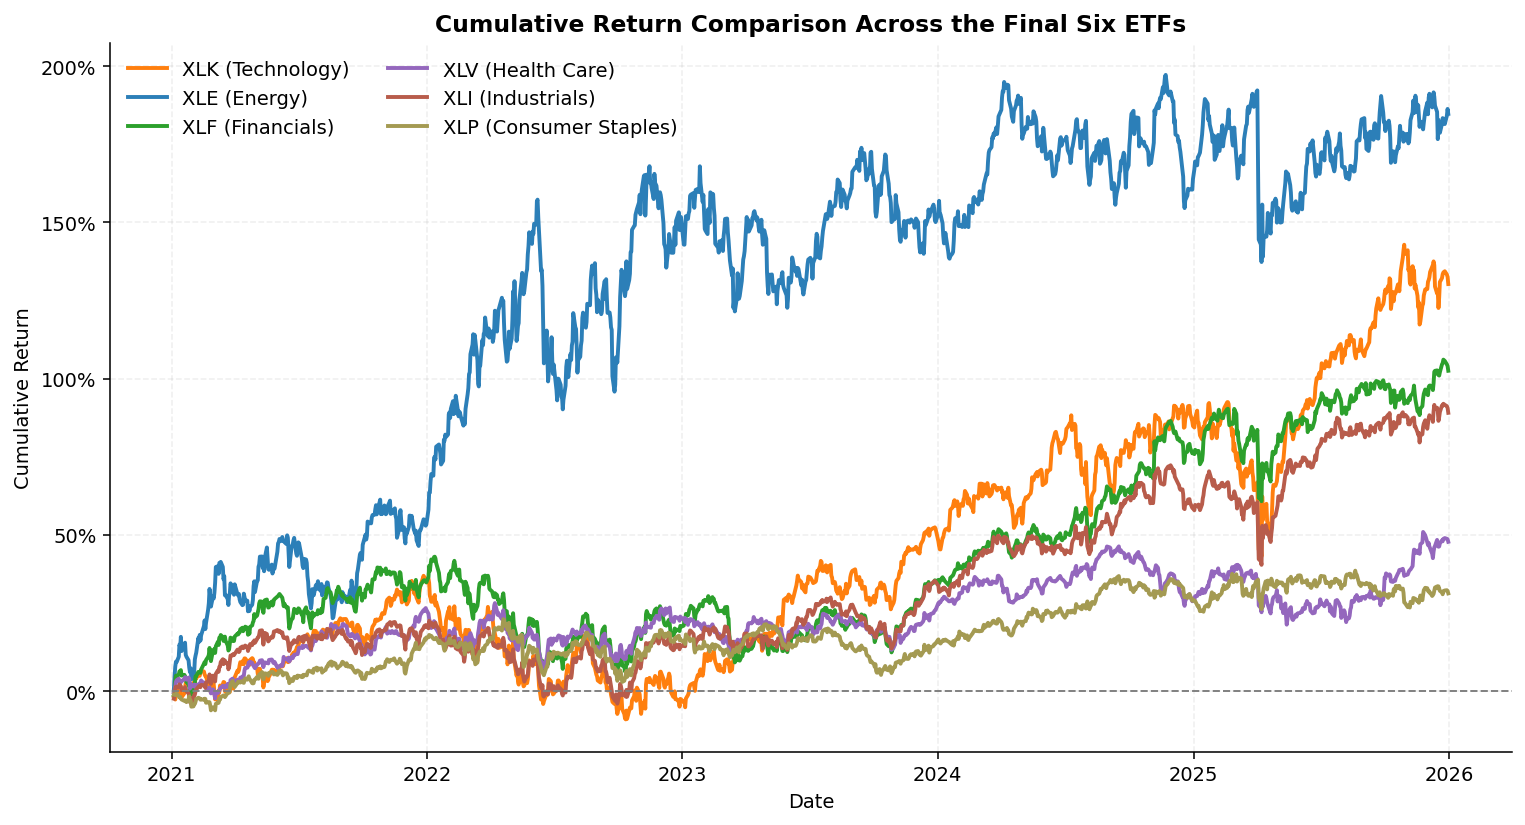

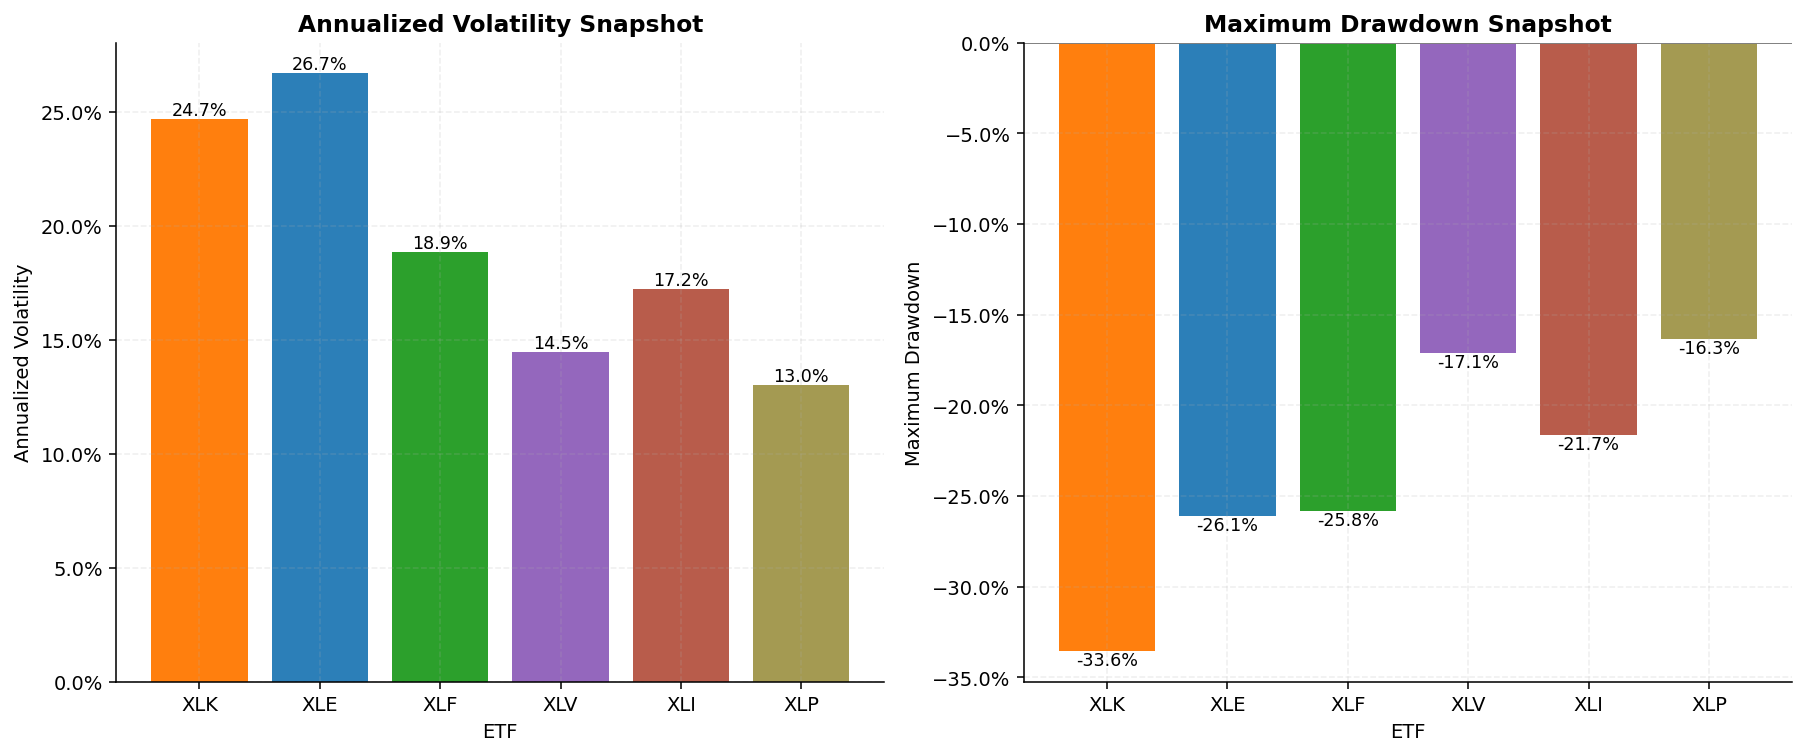

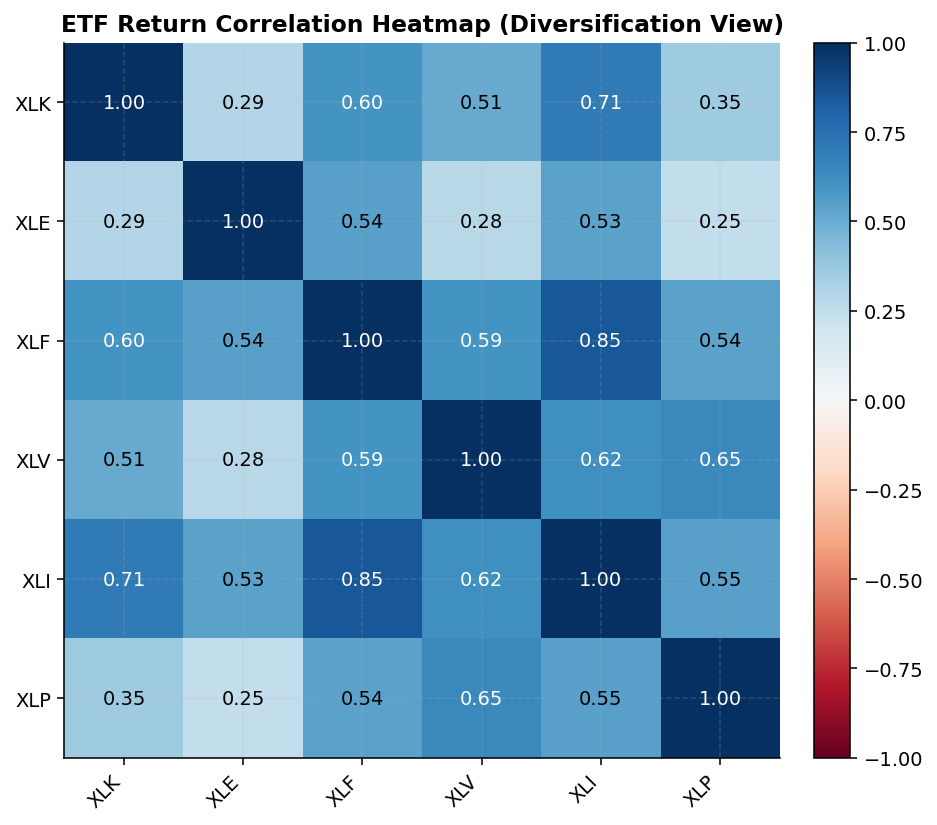

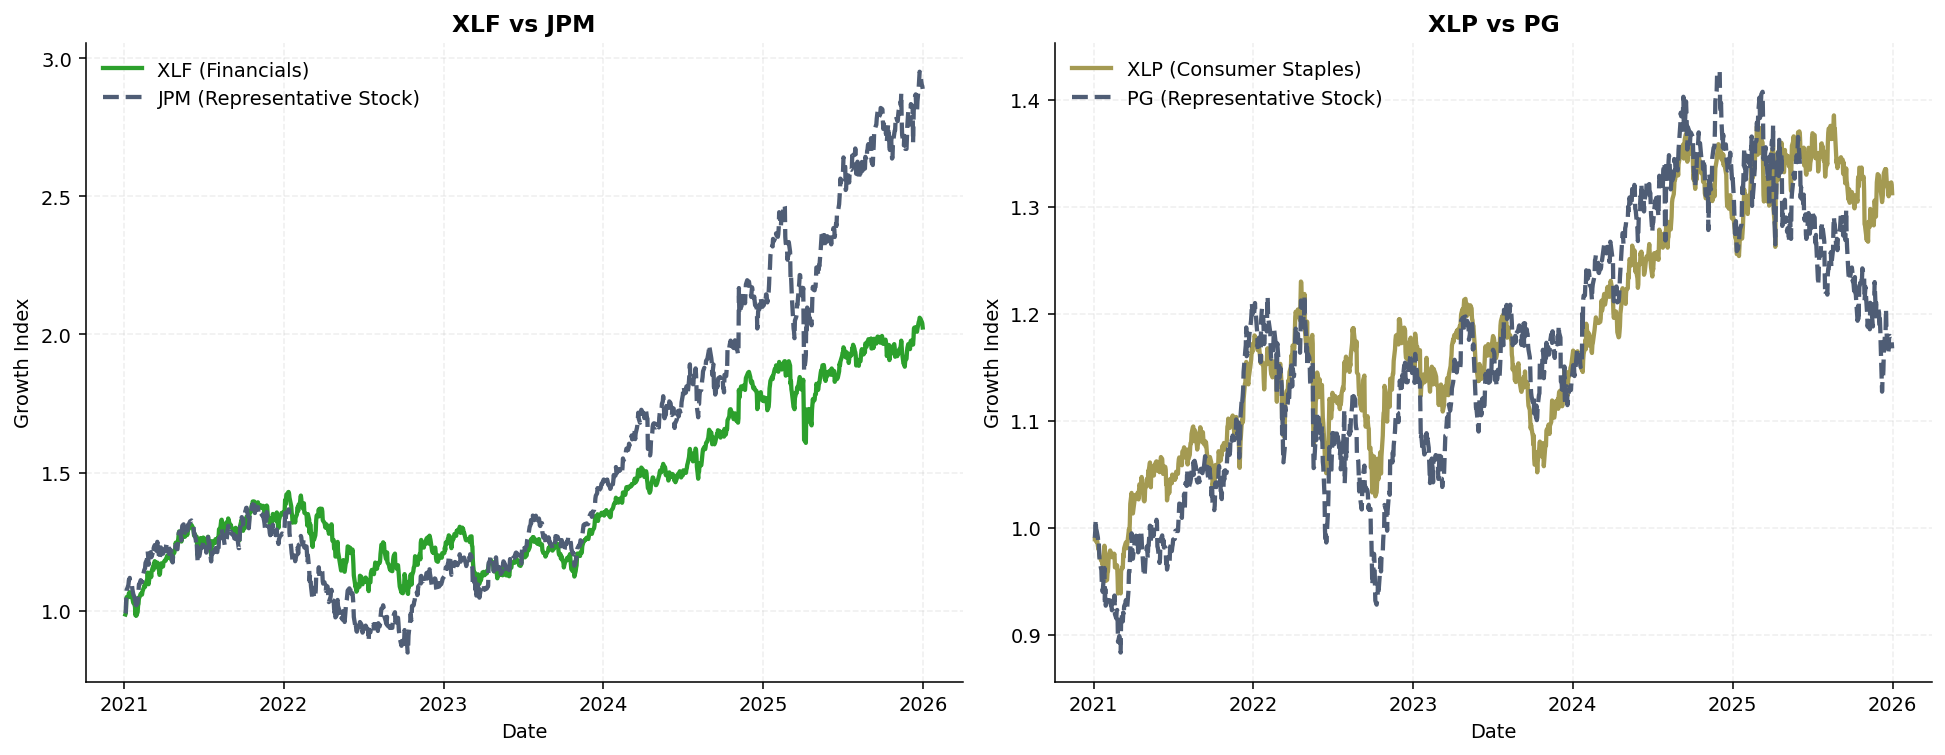

,ETF,ETF_Display_Name,Representative_Stock_Ticker,Representative_Company_Name,Why_Selected
1,XLF,XLF (Financials),JPM,JPMORGAN CHASE & CO,Representative large-cap financial stock
4,XLP,XLP (Consumer Staples),PG,PROCTER & GAMBLE CO,Representative consumer staples stock


,Status,Check,Result
0,Pass,ETF clean file contains all 6 ETFs,True
1,Pass,ETF clean file has no duplicate ticker-date rows,True
2,Pass,ETF summary covers all 6 ETFs,True
3,Pass,Holdings file contains all 6 ETFs,True
4,Pass,Top-10 holdings file has 10 rows per ETF,True
5,Pass,Representative stock mapping contains all 6 ET...,True
6,Pass,Representative stock clean file has no duplica...,True
7,Pass,Representative stock summary covers all 6 ETFs,True
8,Pass,All app-dependent processed files exist,True


,File,Rows,Columns
0,data/processed/etf_prices_clean.csv,7530,10
1,data/processed/etf_prices_metrics_ready.csv,7530,14
2,data/processed/etf_metrics_summary.csv,6,7
3,data/processed/holdings_all_clean.csv,364,11
4,data/processed/holdings_top10.csv,60,11
5,data/processed/representative_stock/representa...,6,16
6,data/processed/representative_stock/representa...,7530,15
7,data/processed/representative_stock/representa...,7530,19
8,data/processed/representative_stock/representa...,6,11


Final validation summary written to data/processed/dataset_validation_summary.txt
Representative stock validation summary written to data/processed/representative_stock/representative_stocks_validation_summary.txt


In [14]:
# ------------------------------
# 1. Reload the saved app-facing outputs
# ------------------------------
etf_prices_clean_final = pd.read_csv(ETF_PRICES_CLEAN_FILE, parse_dates=["Date"])
etf_prices_metrics_ready_final = pd.read_csv(ETF_PRICES_METRICS_READY_FILE, parse_dates=["Date"])
etf_metrics_summary_final = pd.read_csv(
    ETF_METRICS_SUMMARY_FILE,
    parse_dates=["Start_Date", "End_Date"],
)
holdings_all_final = pd.read_csv(HOLDINGS_ALL_FILE, parse_dates=["Holdings_As_Of"])
holdings_top10_final = pd.read_csv(HOLDINGS_TOP10_FILE, parse_dates=["Holdings_As_Of"])
representative_mapping_final = pd.read_csv(
    REP_MAPPING_FILE,
    parse_dates=["Name_Start_Date", "Name_End_Date", "Security_Begin_Date", "Security_End_Date"],
)
representative_stocks_clean_final = pd.read_csv(REP_CLEAN_FILE, parse_dates=["Date"])
representative_stocks_metrics_ready_final = pd.read_csv(REP_METRICS_READY_FILE, parse_dates=["Date"])
representative_stocks_summary_final = pd.read_csv(
    REP_SUMMARY_FILE,
    parse_dates=["Start_Date", "End_Date"],
)

# ------------------------------
# 2. ETF metrics summary table
# ------------------------------
display(
    etf_metrics_summary_final.assign(
        Final_Cumulative_Return=etf_metrics_summary_final["Final_Cumulative_Return"].round(4),
        Annualized_Volatility=etf_metrics_summary_final["Annualized_Volatility"].round(4),
        Max_Drawdown=etf_metrics_summary_final["Max_Drawdown"].round(4),
    )
)

# ------------------------------
# 3. One cumulative return comparison figure
# ------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

for ticker in ETF_UNIVERSE:
    subset = etf_prices_metrics_ready_final.loc[
        etf_prices_metrics_ready_final["Ticker"] == ticker
    ].sort_values("Date")

    ax.plot(
        subset["Date"],
        subset["Cumulative_Return"],
        linewidth=2.0,
        color=COLOR_MAP[ticker],
        label=ETF_DISPLAY_NAME_MAP[ticker],
    )

ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_title("Cumulative Return Comparison Across the Final Six ETFs")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

# ------------------------------
# 4. Risk snapshot: volatility and drawdown
# ------------------------------
risk_snapshot = etf_metrics_summary_final.copy()
risk_snapshot = risk_snapshot.set_index("Ticker").loc[ETF_UNIVERSE].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# 4a. Annualized volatility snapshot
axes[0].bar(
    risk_snapshot["Ticker"],
    risk_snapshot["Annualized_Volatility"],
    color=[COLOR_MAP[ticker] for ticker in risk_snapshot["Ticker"]],
)
axes[0].set_title("Annualized Volatility Snapshot")
axes[0].set_xlabel("ETF")
axes[0].set_ylabel("Annualized Volatility")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

for i, value in enumerate(risk_snapshot["Annualized_Volatility"]):
    axes[0].text(
        i,
        value,
        f"{value:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# 4b. Maximum drawdown snapshot
axes[1].bar(
    risk_snapshot["Ticker"],
    risk_snapshot["Max_Drawdown"],
    color=[COLOR_MAP[ticker] for ticker in risk_snapshot["Ticker"]],
)
axes[1].set_title("Maximum Drawdown Snapshot")
axes[1].set_xlabel("ETF")
axes[1].set_ylabel("Maximum Drawdown")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].axhline(0, color="gray", linewidth=1)

for i, value in enumerate(risk_snapshot["Max_Drawdown"]):
    axes[1].text(
        i,
        value,
        f"{value:.1%}",
        ha="center",
        va="top" if value < 0 else "bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

# ------------------------------
# 5. One diversification output: return correlation heatmap
#    Use a blue end for correlation = 1
# ------------------------------
correlation_matrix = (
    etf_prices_metrics_ready_final
    .pivot(index="Date", columns="Ticker", values="Return")
    .reindex(columns=ETF_UNIVERSE)
    .corr()
)

fig, ax = plt.subplots(figsize=(7, 6))

# RdBu makes the high end (close to +1) blue
heatmap = ax.imshow(correlation_matrix, cmap="RdBu", vmin=-1, vmax=1)

ax.set_title("ETF Return Correlation Heatmap (Diversification View)")
ax.set_xticks(range(len(ETF_UNIVERSE)))
ax.set_yticks(range(len(ETF_UNIVERSE)))
ax.set_xticklabels(ETF_UNIVERSE, rotation=45, ha="right")
ax.set_yticklabels(ETF_UNIVERSE)

for row_index in range(len(ETF_UNIVERSE)):
    for col_index in range(len(ETF_UNIVERSE)):
        value = correlation_matrix.iloc[row_index, col_index]
        ax.text(
            col_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if abs(value) > 0.55 else "black",
        )

fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ------------------------------
# 6. Two representative stock comparison examples
# ------------------------------
example_etfs = ["XLF", "XLP"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

for ax, example_etf in zip(axes, example_etfs):
    example_stock = REPRESENTATIVE_STOCK_MAP[example_etf]

    example_etf_series = etf_prices_metrics_ready_final.loc[
        etf_prices_metrics_ready_final["Ticker"] == example_etf,
        ["Date", "Growth_Index"],
    ].copy().sort_values("Date")

    example_stock_series = representative_stocks_metrics_ready_final.loc[
        representative_stocks_metrics_ready_final["ETF"] == example_etf,
        ["Date", "Growth_Index"],
    ].copy().sort_values("Date")

    ax.plot(
        example_etf_series["Date"],
        example_etf_series["Growth_Index"],
        color=COLOR_MAP[example_etf],
        linewidth=2.2,
        label=ETF_DISPLAY_NAME_MAP[example_etf],
    )
    ax.plot(
        example_stock_series["Date"],
        example_stock_series["Growth_Index"],
        color="#4F5D75",
        linewidth=2.2,
        linestyle="--",
        label=f"{example_stock} (Representative Stock)",
    )

    ax.set_title(f"{example_etf} vs {example_stock}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Growth Index")
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

display(
    representative_mapping_final.loc[
        representative_mapping_final["ETF"].isin(example_etfs),
        [
            "ETF",
            "ETF_Display_Name",
            "Representative_Stock_Ticker",
            "Representative_Company_Name",
            "Why_Selected",
        ],
    ].sort_values("ETF")
)

# ------------------------------
# 7. Final validation and file inventory summary
# ------------------------------
validation_checks = pd.DataFrame(
    [
        {
            "Check": "ETF clean file contains all 6 ETFs",
            "Result": sorted(etf_prices_clean_final["Ticker"].dropna().unique().tolist()) == OUTPUT_ETF_ORDER,
        },
        {
            "Check": "ETF clean file has no duplicate ticker-date rows",
            "Result": int(etf_prices_clean_final.duplicated(subset=["Ticker", "Date"]).sum()) == 0,
        },
        {
            "Check": "ETF summary covers all 6 ETFs",
            "Result": len(etf_metrics_summary_final) == len(ETF_UNIVERSE),
        },
        {
            "Check": "Holdings file contains all 6 ETFs",
            "Result": sorted(holdings_all_final["ETF"].dropna().unique().tolist()) == OUTPUT_ETF_ORDER,
        },
        {
            "Check": "Top-10 holdings file has 10 rows per ETF",
            "Result": bool((holdings_top10_final.groupby("ETF").size().reindex(OUTPUT_ETF_ORDER) == 10).all()),
        },
        {
            "Check": "Representative stock mapping contains all 6 ETF-stock pairs",
            "Result": len(representative_mapping_final[["ETF", "Representative_Stock_Ticker"]].drop_duplicates()) == len(ETF_UNIVERSE),
        },
        {
            "Check": "Representative stock clean file has no duplicate ETF-stock-date rows",
            "Result": int(
                representative_stocks_clean_final.duplicated(
                    subset=["ETF", "Representative_Stock_Ticker", "Date"]
                ).sum()
            ) == 0,
        },
        {
            "Check": "Representative stock summary covers all 6 ETFs",
            "Result": len(representative_stocks_summary_final) == len(ETF_UNIVERSE),
        },
        {
            "Check": "All app-dependent processed files exist",
            "Result": all(
                path.exists()
                for path in [
                    ETF_PRICES_CLEAN_FILE,
                    ETF_PRICES_METRICS_READY_FILE,
                    ETF_METRICS_SUMMARY_FILE,
                    HOLDINGS_ALL_FILE,
                    HOLDINGS_TOP10_FILE,
                    REP_MAPPING_FILE,
                    REP_CLEAN_FILE,
                    REP_METRICS_READY_FILE,
                    REP_SUMMARY_FILE,
                ]
            ),
        },
    ]
)
validation_checks.insert(0, "Status", np.where(validation_checks["Result"], "Pass", "Fail"))

file_inventory = pd.DataFrame(
    [
        {"File": ETF_PRICES_CLEAN_FILE.as_posix(), "Rows": len(etf_prices_clean_final), "Columns": len(etf_prices_clean_final.columns)},
        {"File": ETF_PRICES_METRICS_READY_FILE.as_posix(), "Rows": len(etf_prices_metrics_ready_final), "Columns": len(etf_prices_metrics_ready_final.columns)},
        {"File": ETF_METRICS_SUMMARY_FILE.as_posix(), "Rows": len(etf_metrics_summary_final), "Columns": len(etf_metrics_summary_final.columns)},
        {"File": HOLDINGS_ALL_FILE.as_posix(), "Rows": len(holdings_all_final), "Columns": len(holdings_all_final.columns)},
        {"File": HOLDINGS_TOP10_FILE.as_posix(), "Rows": len(holdings_top10_final), "Columns": len(holdings_top10_final.columns)},
        {"File": REP_MAPPING_FILE.as_posix(), "Rows": len(representative_mapping_final), "Columns": len(representative_mapping_final.columns)},
        {"File": REP_CLEAN_FILE.as_posix(), "Rows": len(representative_stocks_clean_final), "Columns": len(representative_stocks_clean_final.columns)},
        {"File": REP_METRICS_READY_FILE.as_posix(), "Rows": len(representative_stocks_metrics_ready_final), "Columns": len(representative_stocks_metrics_ready_final.columns)},
        {"File": REP_SUMMARY_FILE.as_posix(), "Rows": len(representative_stocks_summary_final), "Columns": len(representative_stocks_summary_final.columns)},
    ]
)

display(validation_checks)
display(file_inventory)

write_text_lines(
    FINAL_VALIDATION_FILE,
    [
        "Final Processed Data Validation Summary",
        "=====================================",
        "",
        "Validation checks:",
        validation_checks.to_string(index=False),
        "",
        "File inventory:",
        file_inventory.to_string(index=False),
    ],
)

write_text_lines(
    REP_VALIDATION_FILE,
    [
        "Representative Stocks Validation Summary",
        "========================================",
        "",
        "Representative stock mapping:",
        representative_mapping_final.to_string(index=False),
        "",
        "Representative stock summary:",
        representative_stocks_summary_final.to_string(index=False),
        "",
        "Representative stock validation checks:",
        validation_checks.loc[
            validation_checks["Check"].str.contains("Representative stock"),
            ["Status", "Check"],
        ].to_string(index=False),
    ],
)

if not validation_checks["Result"].all():
    raise ValueError("One or more final validation checks failed. Review the validation table above.")

print(f"Final validation summary written to {FINAL_VALIDATION_FILE}")
print(f"Representative stock validation summary written to {REP_VALIDATION_FILE}")